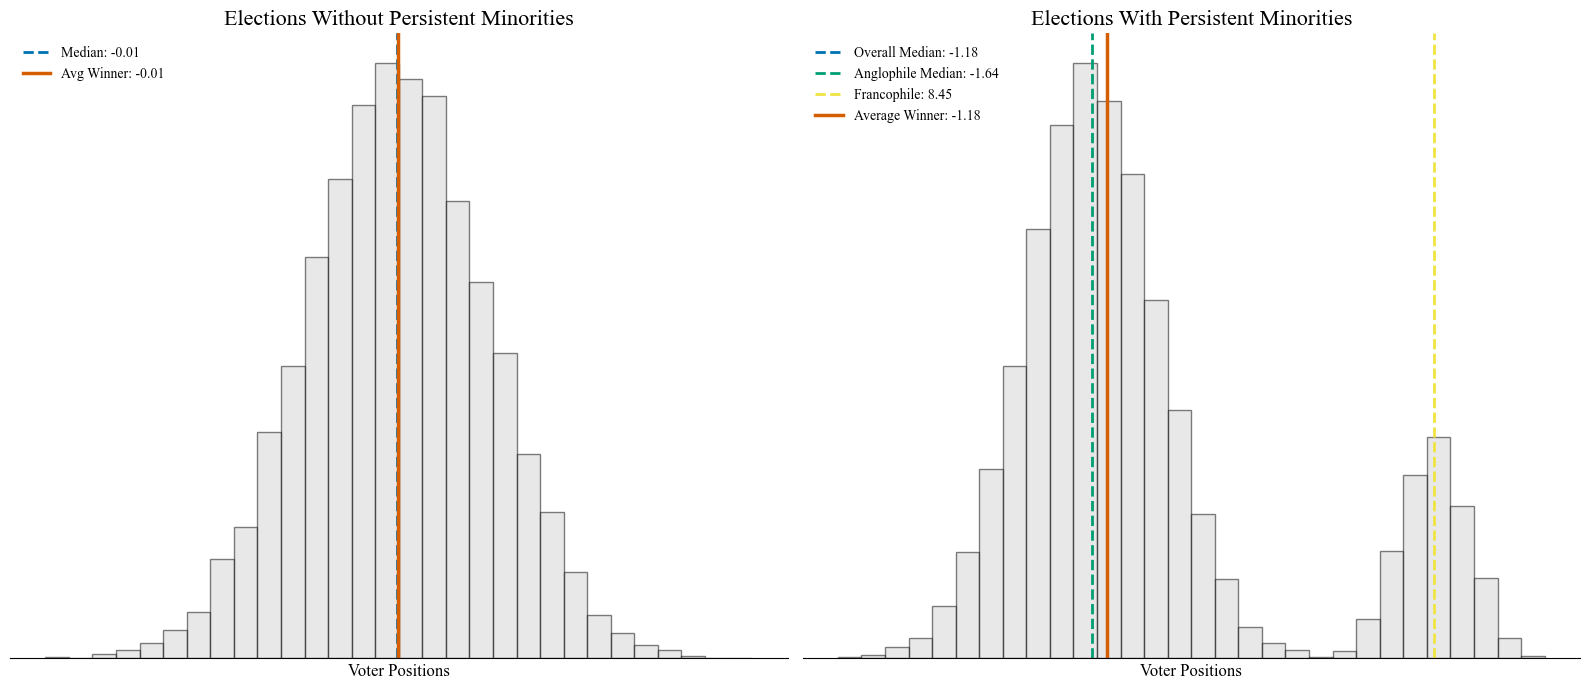

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from collections import Counter

# Generate data for a bimodal distribution
np.random.seed(42)
plt.rcParams["font.family"] = "Times New Roman"

# Parameters for the peaks
large_peak_mean = 10
large_peak_std = 2
large_peak_size = 1000

small_peak_mean = 20
small_peak_std = 1
small_peak_size = 200

# Generate the data
large_peak = np.random.normal(large_peak_mean, large_peak_std, large_peak_size)
small_peak = np.random.normal(small_peak_mean, small_peak_std, small_peak_size)

# Combine the peaks to form a bimodal distribution
bimodal_data = np.concatenate([large_peak, small_peak])

# Fit a Gaussian Mixture Model (GMM) to the data
gmm = GaussianMixture(n_components=2, random_state=42)
bimodal_data_reshaped = bimodal_data.reshape(-1, 1)
gmm.fit(bimodal_data_reshaped)

# Generate samples from the Gaussian Mixture
gmm_samples, _ = gmm.sample(10_000)  # Sample 10,000 points
gmm_samples = gmm_samples.flatten()

# Shift the Gaussian Mixture to have a mean of zero
shifted_gmm_samples = gmm_samples - np.mean(gmm_samples)

# Calculate medians for the shifted data
shifted_median = np.median(shifted_gmm_samples)
shifted_large_peak_median = large_peak.mean() - np.mean(gmm_samples)
shifted_small_peak_median = small_peak.mean() - np.mean(gmm_samples)
shifted_avg_winner_position_gmm = shifted_median  # Placeholder for final analysis

# Generate data for a standard Gaussian distribution
standard_gaussian_samples = np.random.normal(0, 1, 10_000)

# Define a colorblind-friendly palette
colorblind_palette = {
    "avg_winner": "#D55E00",  # Orange-red for average winner
    "overall_median": "#0072B2",  # Blue for overall median
    "large_peak_median": "#009E73",  # Green for large peak median
    "small_peak_median": "#F0E442",  # Yellow for small peak median
}

# Create the plots
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Standard Gaussian distribution (Unimodal)
axes[0].hist(standard_gaussian_samples, bins=30, alpha=0.5, color='lightgray', edgecolor='black', density=True)
axes[0].axvline(np.median(standard_gaussian_samples), color=colorblind_palette["overall_median"], linestyle='--',
                linewidth=2, label=f"Median: {np.median(standard_gaussian_samples):.2f}")
axes[0].axvline(np.mean(standard_gaussian_samples), color=colorblind_palette["avg_winner"], linestyle='-',
                linewidth=2.5, label=f"Avg Winner: {np.mean(standard_gaussian_samples):.2f}")
axes[0].set_title("Elections Without Persistent Minorities", fontsize=16)
axes[0].legend(fontsize=10, loc="upper left", frameon=False)  # Smaller legend in top-left
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['bottom'].set_visible(True)
axes[0].spines['left'].set_visible(False)  # Remove left axis
axes[0].set_xlabel("Voter Positions", fontsize=12)
axes[0].set_yticks([])  # Remove y-axis labels
axes[0].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

# Plot 2: Gaussian Mixture distribution (Bimodal)
axes[1].hist(shifted_gmm_samples, bins=30, alpha=0.5, color='lightgray', edgecolor='black', density=True)
axes[1].axvline(shifted_median, color=colorblind_palette["overall_median"], linestyle='--', linewidth=2,
                label=f"Overall Median: {shifted_median:.2f}")
axes[1].axvline(shifted_large_peak_median, color=colorblind_palette["large_peak_median"], linestyle='--', linewidth=2,
                label=f"Anglophile Median: {shifted_large_peak_median:.2f}")
axes[1].axvline(shifted_small_peak_median, color=colorblind_palette["small_peak_median"], linestyle='--', linewidth=2,
                label=f"Francophile: {shifted_small_peak_median:.2f}")
axes[1].axvline(shifted_avg_winner_position_gmm, color=colorblind_palette["avg_winner"], linestyle='-',
                linewidth=2.5, label=f"Average Winner: {shifted_avg_winner_position_gmm:.2f}")
axes[1].set_title("Elections With Persistent Minorities", fontsize=16)
axes[1].legend(fontsize=10, loc="upper left", frameon=False)  # Smaller legend in top-left
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['bottom'].set_visible(True)
axes[1].spines['left'].set_visible(False)  # Remove left axis
axes[1].set_xlabel("Voter Positions", fontsize=12)
axes[1].set_yticks([])  # Remove y-axis labels
axes[1].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

# Display the plots
plt.tight_layout()
plt.show()
